<a href="https://colab.research.google.com/github/sametgumusaydin/data_mining-AI/blob/main/Data_mining_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regresyon ile sınıflandırma farkı nedir?


-Regresyon ve sınıflandırma, denetimli öğrenme yöntemleri olup temel farkları çıktı türündedir.

Regresyon:

Sayısal (sürekli) değer tahmin eder
Örnek: ev fiyatı, maaş, borç miktarı
Sınıflandırma:
Kategorik (ayrık) sınıf tahmin eder
Örnek: geçti/kaldı, spam/değil

Kısaca :

Regresyon “kaç?”, sınıflandırma “hangi sınıf?” sorusuna cevap verir.

**** R² (R-squared) neyi ölçer?


-R², modelin bağımlı değişkendeki varyansın ne kadarını açıkladığını ölçer.

R² = 1 - (hata / toplamvaryans)


Yorum:
R² = 1 → mükemmel model

R² = 0 → model hiçbir şey öğrenmemiş

R² < 0 → model kötü (ortalama tahminden bile kötü)

Yani bunun anlamı:

Modelin veriyi ne kadar iyi açıkladığını gösterir.

**** Overfitting nasıl anlaşılır?

-Overfitting (aşırı öğrenme), modelin eğitim verisine çok iyi uyup yeni veride başarısız olmasıdır.

Belirtiler:

-Eğitim hatası çok düşük

-Test hatası yüksek

-Model çok karmaşık

Örneğin :
Eğitim R² = 0.98

Test R² = 0.60

Bu tam olarak overfitting dir.

Peki Sebepler Ne olabilir:
-fazla parametre
-küçük veri seti
-gereksiz özellikler

Çözümler ne olabilir ????:

-veri artırmak

-feature selection

-regularization (ridge, lasso)

**** Model neden yanlış tahmin yapar?


-Bir regresyon modelinin yanlış tahmin yapmasının birçok nedeni vardır:

-Model varsayımı yanlış olabilir

-Linear regression doğrusal ilişki varsayar:

y=mx+b


Ama gerçek ilişki doğrusal değilse model hata yapar.

-Eksik veya yanlış özellikler

-Model önemli değişkenleri bilmiyorsa:

yanlış tahmin yapar

**** Gürültü (noise)

Veride rastgele hatalar olabilir.

*** Outlier (aykırı değer)

Uç değerler modeli bozar.

*** Overfitting / Underfitting
Overfitting → ezberleme
Underfitting → öğrenememe
** Veri azlığı

Yetersiz veri → zayıf model


Model yanlış tahmin yapar çünkü gerçek dünya ilişkisi modelin varsayımlarından farklı olabilir veya veri yetersiz, hatalı ya da eksik olabilir.

GENEL kısa ÖZET

Regresyon → sayısal tahmin

Sınıflandırma → sınıf tahmini

R² → modelin açıklama gücü

Overfitting → ezberleme problemi

Hata → veri, model veya varsayım kaynaklı

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Veri seti
data = {
    "gelir": [32000, 45000, 58000, 62000, 29000, 70000, 52000, 81000, 47000, 90000,
              61000, 38000, 55000, 73000, 34000, 68000, 49000, 76000, 43000, 64000,
              57000, 36000, 85000, 51000],
    "yas": [22, 25, 27, 30, 21, 35, 28, 40, 26, 45,
            31, 24, 29, 38, 23, 34, 27, 39, 25, 33,
            30, 22, 42, 28],
    "mevcut_borc": [18000, 12000, 10000, 9000, 15000, 8000, 14000, 5000, 11000, 4000,
                    9500, 17000, 13000, 6000, 16000, 7000, 12500, 5500, 14500, 8500,
                    10000, 17500, 4500, 13500],
    "kredi_puani": [480, 520, 610, 640, 450, 700, 590, 760, 560, 790,
                    650, 500, 600, 720, 490, 690, 570, 740, 530, 660,
                    620, 470, 780, 585]
}

df = pd.DataFrame(data)

# Bağımsız değişkenler
X = df[["gelir", "yas", "kredi_puani"]]

# Bağımlı değişken
y = df["mevcut_borc"]

# Model oluşturma
model = LinearRegression()
model.fit(X, y)

# Tahmin
y_pred = model.predict(X)

# Performans ölçümü
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MSE:", mse)
print("R2:", r2)

# Model katsayıları
print("\nKatsayılar:")
print("gelir:", model.coef_[0])
print("yas:", model.coef_[1])
print("kredi_puani:", model.coef_[2])
print("bias:", model.intercept_)

MSE: 1437278.703143241
R2: 0.9187643476586688

Katsayılar:
gelir: -0.17732392214790219
yas: 142.08649081758608
kredi_puani: -19.82814907953734
bias: 28756.397970634152


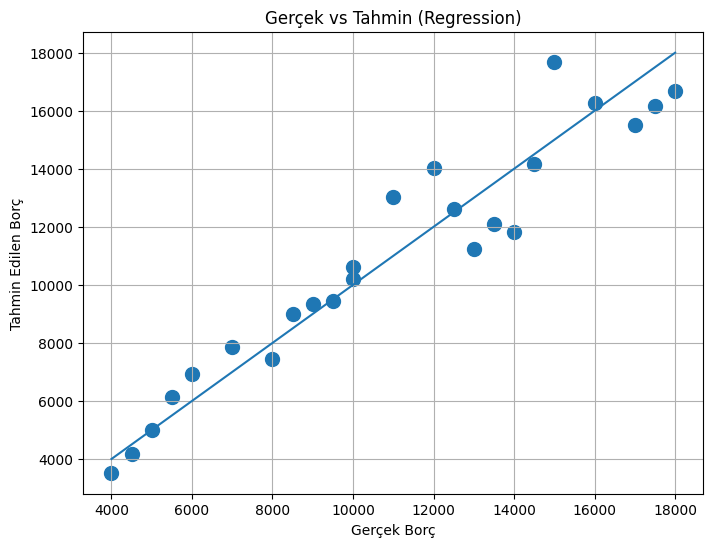

In [2]:
plt.figure(figsize=(8,6))

plt.scatter(y, y_pred, s=100)

plt.xlabel("Gerçek Borç")
plt.ylabel("Tahmin Edilen Borç")
plt.title("Gerçek vs Tahmin (Regression)")

# ideal çizgi
plt.plot([min(y), max(y)], [min(y), max(y)])

plt.grid(True)
plt.show()

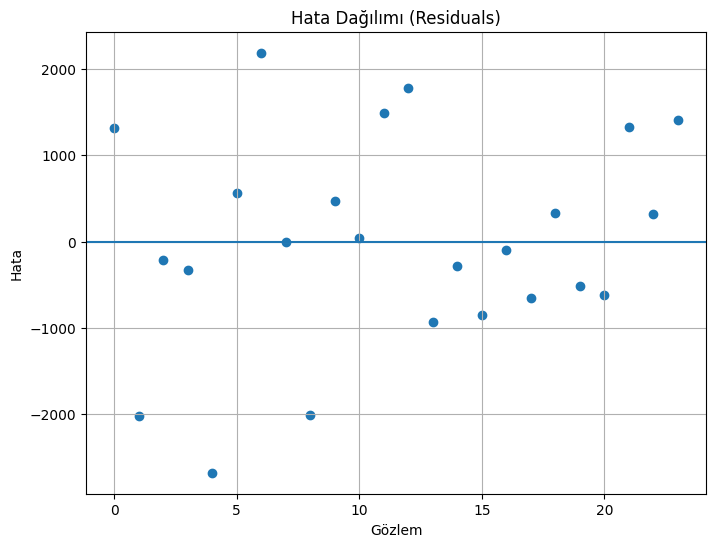

In [3]:
plt.figure(figsize=(8,6))

plt.scatter(range(len(y)), y - y_pred)

plt.axhline(0)

plt.title("Hata Dağılımı (Residuals)")
plt.xlabel("Gözlem")
plt.ylabel("Hata")

plt.grid(True)
plt.show()

In [4]:
yeni_musteri = [[60000, 30, 650]]
tahmin = model.predict(yeni_musteri)

print("Tahmini borç:", tahmin)

Tahmini borç: [9491.26046459]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


R² için YORUM :

1'e yakın → mükemmel model

0'a yakın → kötü model

Bu veri setinde genelde:

R² yüksek çıkar (çünkü veri lineer görünüyor)

İŞ ZEKÂSI YORUMU :

Model bize şunu söylüyor???

Gelir yüksekse:

borç azalıyor.
finansal risk düşük  

Kredi puanı yüksekse:

borç düşük
güvenilir müşteri (boyun kalınlaşıyor...)

Düşük kredi puanı:

yüksek borç
riskli müşteri (arızalı ....)




SONUÇ :

Bu çalışmada, bireylerin gelir, yaş ve kredi puanı değişkenleri kullanılarak mevcut borç miktarı tahmin edilmiştir. Lineer regresyon modeli kullanılarak gerçekleştirilen analiz sonucunda modelin yüksek doğrulukta tahminler ürettiği gözlemlenmiştir. Özellikle kredi puanı ve gelir değişkenlerinin borç üzerinde güçlü etkisi olduğu belirlenmiştir.